# Demonstration of Single Telescope Tasking Problem

Yuri Shimane, 2024/09/12

In [4]:
using Pkg
Pkg.activate("../")         # we activate the environment in the root directory of the project

  Activating project at `c:\Users\yshimane3\Documents\codes\dev-julia\TelescopeTasking.jl`


In [38]:
using Colors
using ColorSchemes
using GeometryBasics
using GLMakie
using HiGHS                             # using HiGHS, but could be Gurobi, GLPK, etc.
using JuMP
using JSON
using LinearAlgebra
using ProgressMeter: @showprogress
using Printf: @printf
using SatelliteToolboxTle
using SatelliteToolboxSgp4
using SatelliteToolboxTransformations

In [59]:
Makie.inline!(true)

true

In [5]:
include(joinpath(@__DIR__, "../src/TelescopeTasking.jl"))

Main.TelescopeTasking

In [8]:
# load Earth parameters
# eop_iau1980 = fetch_iers_eop()                                                    # could either call this, or
eop_file = joinpath(@__DIR__, "..", "data", "eop_iau1980", "finals.all.csv")        # load from the saved data in the repo
eop_iau1980 = read_iers_eop(eop_file, Val(:IAU1980));

### Loading TLEs

We first load the tles as string

In [98]:
# load TLE files
path_to_tles = joinpath(@__DIR__, "..", "data", "tles", "active.txt")
tles_str = read(path_to_tles, String)

"CALSPHERE 1             \r\n1 00900U 64063C   24248.52151727  .00002333  00000+0  24182-2 0  9997\r\n2 00900  90.2030  57.0645 0027650 100.6982 324.6933 13.75273375981931\r\nCALSPHERE 2             \r\n1 00902U 64063E   24248.60630124  .00000106  00000+0  14707-3 0  9990\r\n2 00" ⋯ 1715247 bytes ⋯ "8  00000+0  24897-2 0  9996\r\n2 60957  51.6404 286.5066 0012900 319.6447  40.3692 15.51209936  2803\r\n1998-067WY              \r\n1 60958U 98067WY  24247.66719863  .00094452  00000+0  15904-2 0  9997\r\n2 60958  51.6408 286.5055 0014036 317.7376  42.2529 15.50818434   815\r\n"

We then convert them into a list of tle objects

In [99]:
 # convert to TLE objects
 tles = read_tles(tles_str)

10213-element Vector{TLE}:
 TLE: CALSPHERE 1 (Epoch = 2024-09-04T12:30:59.092)
 TLE: CALSPHERE 2 (Epoch = 2024-09-04T14:33:04.427)
 TLE: LCS 1 (Epoch = 2024-09-04T11:16:31.016)
 TLE: TEMPSAT 1 (Epoch = 2024-09-04T09:48:28.563)
 TLE: CALSPHERE 4A (Epoch = 2024-09-04T13:43:49.942)
 TLE: OPS 5712 (P/L 160) (Epoch = 2024-09-04T14:14:38.759)
 TLE: LES-5 (Epoch = 2024-09-04T15:29:44.559)
 TLE: SURCAL 159 (Epoch = 2024-09-04T14:29:22.025)
 TLE: OPS 5712 (P/L 153) (Epoch = 2024-09-04T14:08:08.448)
 TLE: SURCAL 150B (Epoch = 2024-09-04T13:24:58.939)
 ⋮
 TLE: YAOGAN-43 02E (Epoch = 2024-09-04T15:11:23.449)
 TLE: YAOGAN-43 02F (Epoch = 2024-09-04T15:11:28.444)
 TLE: 1998-067WS (Epoch = 2024-09-03T14:27:55.005)
 TLE: 1998-067WT (Epoch = 2024-09-03T16:00:38.634)
 TLE: 1998-067WU (Epoch = 2024-09-03T14:27:34.536)
 TLE: 1998-067WV (Epoch = 2024-09-03T14:25:48.458)
 TLE: 1998-067WW (Epoch = 2024-09-03T14:27:29.754)
 TLE: 1998-067WX (Epoch = 2024-09-03T16:00:15.207)
 TLE: 1998-067WY (Epoch = 2024-09-03

and we finally filter them based on names (if need be)

In [100]:
# filter them
names_include = ["GLOBALSTAR", "IRIDIUM", "ORBCOMM"]
tles = TelescopeTasking.filter(tles, names_include = names_include)
@printf("%d objects after filtering for: ", length(tles))
println(names_include)

123 objects after filtering for: ["GLOBALSTAR", "IRIDIUM", "ORBCOMM"]


We can propagate the orbits in ECI

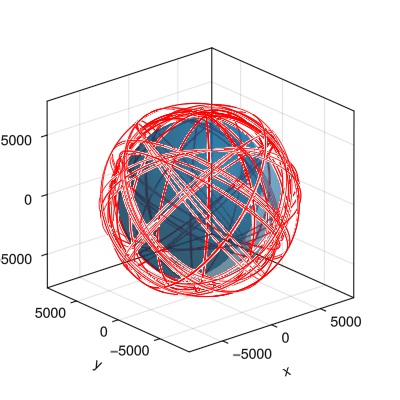

GLMakie.Screen(...)

In [101]:
# propagation time: 3 hours, expressed in minutes
dts_min = 0:dt_min:3*60

# initialize figure
fig = Figure(size=(400, 400))
ax3 = Axis3(fig[1,1], aspect=:data)
@showprogress for _tle in tles
    _sgp4d = sgp4_init(_tle)                                                    # initialize SGP4 propagator for TLE
    _rs_teme, _vs_teme = zeros(3, length(dts_min)), zeros(3, length(dts_min))   # initialize storage

    # propagate
    for (_idx,_dt_min) in enumerate(dts_min)
        _rs_teme[:,_idx], _vs_teme[:,_idx] = sgp4!(_sgp4d, _dt_min)
    end
    lines!(ax3, _rs_teme[1,:], _rs_teme[2,:], _rs_teme[3,:], color=:red, linewidth=0.8)
end

# plot Earth
mesh!(ax3, Sphere(GeometryBasics.Point3f0(0), 6378.0), alpha=0.7)
display(fig)

### Pass computation

In [102]:
# get latext epoch within all TLEs considered
jd0_ref = maximum([tle_epoch(tle) for tle in tles])

# get passes
obs_duration = 8 * 3600             # in seconds
min_elevation = deg2rad(30)
min_obs_duration = 100              # in seconds
exposure_duration = 60              # in seconds
observer_lat = deg2rad(45)
observer_lon = deg2rad(100)
observer_alt = 30.0
observer_lla = [observer_lat, observer_lon, observer_alt]

passes, sph_ENU_list = TelescopeTasking.tles_to_passes(
    tles,
    eop_iau1980,
    jd0_ref,
    obs_duration,
    min_elevation,
    min_obs_duration,
    exposure_duration,
    observer_lla,
    dt_sec=10,
);
@printf("Detected %d passes\n", length(passes))

Detected 124 passes


In [103]:
passes[1]

Visible Pass of IRIDIUM 122 (designator 17061C)
    Exposure start:        2.4605581198495436e6 JD
    Exposure end:          2.460558120543988e6 JD
    Max elevation:         51.75447572858449 deg
    Pass duration (min):   4.4999997317790985 min
    Number of data points: 28


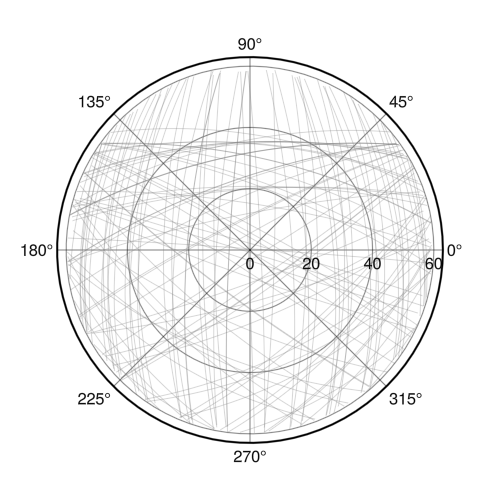

GLMakie.Screen(...)

In [104]:
# plot of selected passes
fig_passes = Figure(size=(500,500))
ax_passes = PolarAxis(fig_passes[1,1])
TelescopeTasking.polar_plot_passes!(ax_passes, passes; color=:grey, linewidth=0.3)
display(fig_passes)

### Construct and solve Single Telescope Tasking Problem (STTP)

In [105]:
# construct problem
num_exposure = 1
slew_rate = deg2rad(2)      # rad/s
buffer_times = [15, 0]      # times in seconds
problem = TelescopeTasking.TelescopeTaskingProblem(
    passes, num_exposure,
    slew_rate;
    buffer_times = buffer_times
)

Telescope Scheduling Problem instance
    Number of passes n  = 124
    Number of targets m = 82


In [106]:
# solve
solver = HiGHS.Optimizer
X, Y, status = TelescopeTasking.solve(problem, solver)
selected_passes = [pass for (pass, y) in zip(passes, value.(Y)) if y > 0.5];

Created variables; 0.0010 sec
Created sufficient exposure constraint; 0.0010 sec
Created transition feasibility constraint; 0.0110 sec
Model created; elapsed time; 0.0110 sec
Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [1e+00, 1e+00]
  Bound  [1e+00, 1e+00]
  RHS    [1e+00, 2e+00]
Presolving model
101 rows, 117 cols, 213 nonzeros  0s
19 rows, 30 cols, 39 nonzeros  0s
15 rows, 26 cols, 31 nonzeros  0s
6 rows, 17 cols, 13 nonzeros  0s
4 rows, 8 cols, 10 nonzeros  0s
3 rows, 6 cols, 7 nonzeros  0s
3 rows, 5 cols, 7 nonzeros  0s
Objective function is integral with scale 1

Solving MIP model with:
   3 rows
   5 cols (5 binary, 0 integer, 0 implied int., 0 continuous)
   7 nonzeros

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
     Proc. InQueue |  Leaves   Expl. | BestBound       BestSol              Gap |   Cuts  

In [107]:
# save to dictionary
solution_dict = TelescopeTasking.STTP_solution_to_dict(
    passes,
    jd0_ref,
    obs_duration,
    min_elevation,
    min_obs_duration,
    exposure_duration,
    observer_lla,
    X,
    Y,
)
open(joinpath(@__DIR__, "example_STTP_solution.json"), "w") do io
    write(io, JSON.json(solution_dict))
end;

### Visualization of results

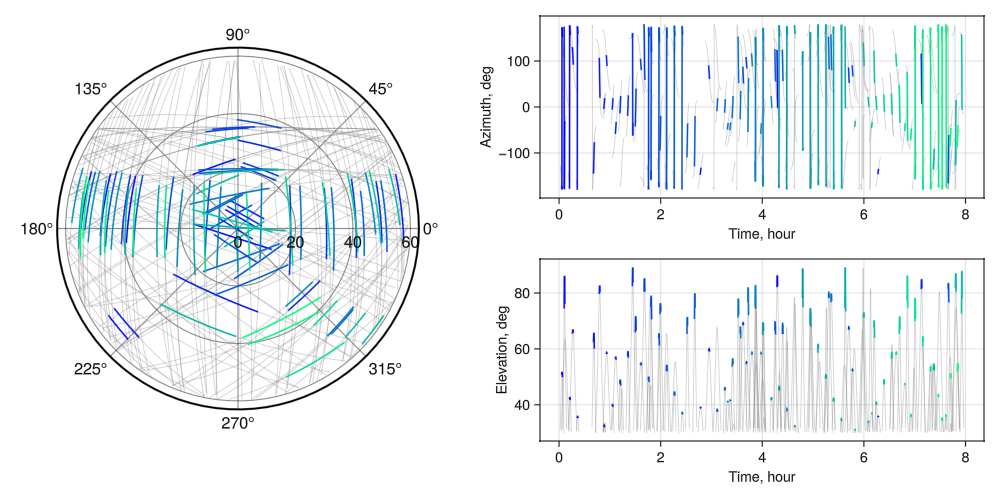

GLMakie.Screen(...)

In [108]:
# initialize figure
fig_sol = Figure(size=(1000,500))

# plot of selected passes
ax_sol = PolarAxis(fig_sol[1:2,1])
TelescopeTasking.polar_plot_passes!(ax_sol, passes; color=:grey, linewidth=0.3)
TelescopeTasking.polar_plot_passes!(ax_sol, selected_passes; 
    linewidth=1.5, color_by_target=true, exposure_only=true)
    
# plot time-history
axes = [Axis(fig_sol[1,2]; xlabel="Time, hour", ylabel="Azimuth, deg"),
Axis(fig_sol[2,2]; xlabel="Time, hour", ylabel="Elevation, deg")]
TelescopeTasking.plot_time_history!(axes, passes; jd_ref=jd0_ref, color=:grey, linewidth=0.3)
TelescopeTasking.plot_time_history!(axes, selected_passes; jd_ref=jd0_ref, 
    linewidth=1.5, color_by_target=true, exposure_only=true)

# display & save
save(joinpath(@__DIR__, "example_STTP_solution.png"), fig_sol)
display(fig_sol)

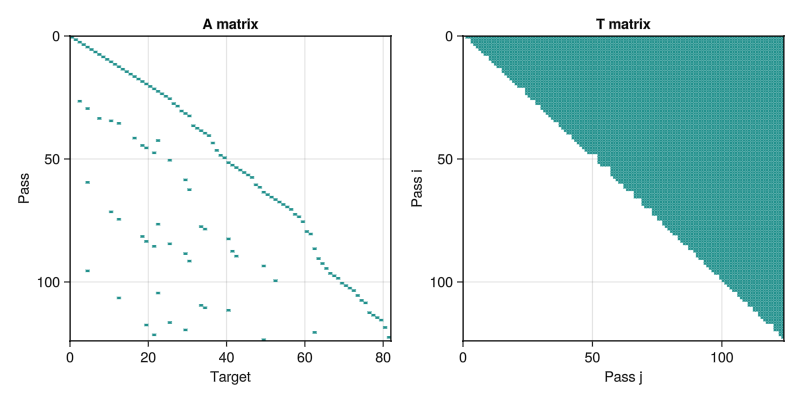

GLMakie.Screen(...)

In [109]:
# plot sparsity of T and A
fig_spy = Figure(size=(800,400))
ax_spy_A = Axis(fig_spy[1,1]; title="A matrix", xlabel="Target", ylabel="Pass", yreversed=true)
spy!(ax_spy_A, transpose(problem.A))
ax_spy_T = Axis(fig_spy[1,2]; title="T matrix", xlabel="Pass j", ylabel="Pass i", yreversed=true)
spy!(ax_spy_T, transpose(problem.T))
display(fig_spy)